# Multi-shot Variable-Density Spiral SE Diffusion

This notebook builds a multi-shot spin-echo diffusion sequence with a variable-density spiral readout in the local pSeq framework.

## Outline
1. Configure protocol and hardware limits.
2. Build RF/fat-sat and VDS spiral readout blocks.
3. Define diffusion directions.
4. Assemble the full multi-slice, multi-direction diffusion sequence.
5. Run timing QA and export the sequence.

## Design Notes
- VDS profile follows a constrained radial-spiral integration with gradient and slew limits.
- FOV profile is polynomial in normalized radius (`fov_coeff`).
- Interleaves are generated by rotating a base trajectory by `2*pi/n_shots`.

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import pypulseq as pp
from pSeq import (
    pSeq_Base,
    pSeq_RF,
    pSeq_FatSat,
    pSeq_Diffusion,
    pSeq_Spiral_VDS,
    pSeq_GRE_multi_echo
)

In [173]:
# ------------------------------
# User-facing protocol parameters
# ------------------------------
fov = 200e-3
nx = 160
ny = 160
n_shots = 16

# Spiral acceleration factor (in-plane undersampling).
# Typical useful range for blur reduction: 2.0 - 4.0
# spiral_accel = 2.0
spiral_accel = 1.5
# spiral_accel = 1.0

# Variable-density FOV profile: F(r) = fov * (c0 + c1*x + c2*x^2 + ...), x=r/rmax
# Keep profile positive over x in [0, 1].
fov_coeff = [1.0, 0.0, -0.35]

n_slices = 3
slice_thickness = 5e-3
slice_gap = 20e-3
slice_offsets = (np.arange(n_slices) - (n_slices - 1) / 2.0) * (slice_thickness + slice_gap)

num_repeats = 2
TR_sec = 500e-3
b_value = 8000

print(f'FOV={fov*1e3:.1f} mm, Matrix={nx}x{ny}, Shots={n_shots}')
print(f'Spiral acceleration={spiral_accel:.2f}x')
print(f'FOV coeff={fov_coeff}')
print(f'Slices={n_slices}, Repeat={num_repeats}, b={b_value} s/mm^2')

FOV=200.0 mm, Matrix=160x160, Shots=16
Spiral acceleration=1.50x
FOV coeff=[1.0, 0.0, -0.35]
Slices=3, Repeat=2, b=8000 s/mm^2


In [174]:
# --------------------------------------------------------
# Build hardware limits and reusable RF/FatSat blocks
# --------------------------------------------------------
system_max = pp.Opts(
    max_grad=200, grad_unit='mT/m',
    max_slew=200, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_diff = pp.Opts(
    max_grad=160, grad_unit='mT/m',
    max_slew=80, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_spiral = pp.Opts(
    max_grad=100, grad_unit='mT/m',
    max_slew=70, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_low = pp.Opts(
    max_grad=30, grad_unit='mT/m',
    max_slew=30, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_sp = pSeq_Base(system=system_max)

fatsat = pSeq_FatSat(system=system_low, type='FatSat2')
fatsat.prep_fatsat()

rf90 = pSeq_RF(
    system=system_low,
    flip_angle=np.pi / 2,
    duration=3e-3,
    thickness=slice_thickness,
    use='excitation',
)
rf90.prep()

rf180 = pSeq_RF(
    system=system_low,
    flip_angle=np.pi,
    duration=6e-3,
    thickness=slice_thickness,
    use='refocusing',
    do_refocus=False,
    crusher_area=100,
    crusher_axis=['x', 'y', 'z'],
)
rf180.prep()

trig = pp.make_digital_output_pulse('ext1', duration=20e-6)

-220.3308
0.003 0.003
-220.3308
Fat Sat: The peak rf_fs Amplitude =  1.6253962983488777e-06 uT
Making Sinc Pulse with flip angle 90.0
Making SLR Pulse with flip angle 90.0
excitation : The peak rf Amplitude =  7.797889527969152 uT
Making Sinc Pulse with flip angle 180.0
Making SLR Pulse with flip angle 180.0
refocusing : The peak rf Amplitude =  7.797889596354154 uT
Prepared crusher gradients for refocusing pulse on ['x', 'y', 'z']-axis with area 100 1/m


e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_FatSat.py:36: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  self.rf_fs = pp.make_gauss_pulse(110 * np.pi / 180, system=self.system, duration=8e-3,
e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_RF.py:64: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  self.rf, self.gz, self.gzReph = pp.make_sinc_pulse(flip_angle = self.flip_angle,
e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_RF.py:80: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rfp,gz,gzr = make_sigpy_pulse.sigpy_n_seq(flip_angle = self.flip_angle,  freq_offset = 0, phase_offset = self.phase_offset,


Spiral summary: {'adc_samples': 4528, 'adc_dwell': 1e-06, 'adc_bandwidth_hz': 1000000.0, 'center_hold_duration': 3.0000000000000004e-05, 'accel_requested': 1.5, 'accel_effective': 1.5, 'readout_duration': 0.00455, 'rampdown_duration': 0.00033000000000000043, 'rewinder_duration': 0.0007800000000000001, 'shot_duration': 0.005660000000000001, 'kmax': 400.0}
Readout duration per shot: 4.55 ms
Total shot duration (with rewinder): 5.66 ms


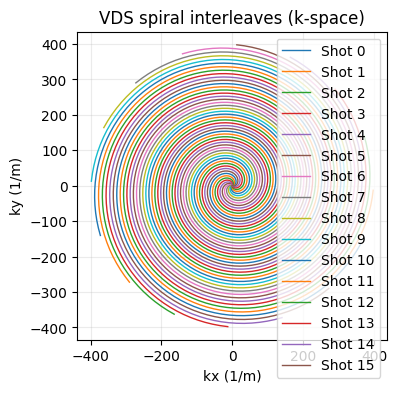

In [175]:
# --------------------------------------------------------
# Prepare multishot variable-density spiral readout
# --------------------------------------------------------
spiral_vds = pSeq_Spiral_VDS(
    system=system_spiral,
    fov=fov,
    nx=nx,
    ny=ny,
    n_interleaves=n_shots,
    fov_coeff=fov_coeff,
    accel=spiral_accel,
    oversamp=4,
)
summary = spiral_vds.prep(adc_dwell=1e-6)
print('Spiral summary:', summary)
print(f"Readout duration per shot: {summary['readout_duration']*1e3:.2f} ms")
print(f"Total shot duration (with rewinder): {summary['shot_duration']*1e3:.2f} ms")

k0 = spiral_vds.get_ktraj(interleaf=0)
plt.figure(figsize=(4, 4))
for shot_idx in range(n_shots):
    ks = spiral_vds.get_ktraj(interleaf=shot_idx)
    plt.plot(np.real(ks), np.imag(ks), lw=1.0, label=f'Shot {shot_idx}')
plt.title('VDS spiral interleaves (k-space)')
plt.xlabel('kx (1/m)')
plt.ylabel('ky (1/m)')
plt.axis('equal')
plt.grid(True, alpha=0.25)
plt.legend()
# plt.xlim(-1,1)
# plt.ylim(-1,1)
plt.show()

In [176]:
# -------------------------------------------------------------
# Fixed diffusion direction set (b0 + 6 cardinal directions)
# -------------------------------------------------------------
diff_dirs = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [-1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, -1.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, -1.0],
], dtype=float)

dir_labels = ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']
num_dirs = diff_dirs.shape[0]
print('Using diffusion directions:', dir_labels)

Using diffusion directions: ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']


In [177]:
# ---------------------------------------------------------------------
# Sequence assembly (multi-slice diffusion with multishot VDS spiral)
# Loop order: repeat -> slice -> direction -> shot
# ---------------------------------------------------------------------
seq_sp = pSeq_Base(system=system_max)

diffusion = pSeq_Diffusion(
    system=system_diff,
    channel='x',
    target_b_s_mm2=b_value,
    max_lobe_duration=40e-3,
)

_ = diffusion.prep_monopolar(
    rf90=rf90,
    rf180=rf180,
    epi=spiral_vds,
    extra_pre_delay_s=0.0,
    verbose=True,
)

print(f'Designed diffusion b(actual): {diffusion.b_actual_s_mm2:.2f} s/mm^2')
print(f'Designed TE(min): {diffusion.te*1e3:.2f} ms')

total_shots = 0
tr_violations = 0

for rep in range(num_repeats):
    for slc_idx, slc_offset in enumerate(slice_offsets):
        rf90.offset_rf(offset=slc_offset)
        rf180.offset_rf(offset=slc_offset)

        for dir_idx, diff_dir in enumerate(diff_dirs):
            for shot_idx in range(n_shots):
                total_shots += 1
                t_start = seq_sp.seq.duration()[0] if len(seq_sp.seq.block_events) > 0 else 0.0

                lrep = pp.make_label(type='SET', label='REP', value=rep)
                lslc = pp.make_label(type='SET', label='SLC', value=slc_idx)
                lseg = pp.make_label(type='SET', label='SEG', value=dir_idx)
                lavg = pp.make_label(type='SET', label='AVG', value=shot_idx)
                seq_sp.seq.add_block(lrep, lslc, lseg, lavg, trig)

                g0, g1 = diffusion.get_rotated_lobes(diff_dir)

                seq_sp.add_pseq_to_self(fatsat)
                seq_sp.add_pseq_to_self(rf90)
                seq_sp.seq.add_block(*g0)

                if diffusion.delay1 > 0:
                    seq_sp.seq.add_block(pp.make_delay(diffusion.delay1))

                seq_sp.add_pseq_to_self(rf180)
                seq_sp.seq.add_block(*g1)

                if diffusion.delay2 > 0:
                    seq_sp.seq.add_block(pp.make_delay(diffusion.delay2))

                spiral_vds.add_to_seq(seq_sp, interleaf=shot_idx, label=False, add_rewinder=True)

                t_end = seq_sp.seq.duration()[0]
                shot_dur = t_end - t_start
                tr_pad = TR_sec - shot_dur

                if tr_pad > system_max.grad_raster_time:
                    tr_pad = np.ceil(tr_pad / system_max.grad_raster_time) * system_max.grad_raster_time
                    seq_sp.seq.add_block(pp.make_delay(tr_pad))
                elif tr_pad < -1e-6:
                    tr_violations += 1

print(f'Total shots added: {total_shots}')
print(f'TR violations: {tr_violations}')
print(f'Estimated sequence duration: {seq_sp.seq.duration()[0]:.2f} s')

Diffusion designer summary:
  target b: 8000.00 s/mm^2
  actual b: 8000.00 s/mm^2
  lobe amplitude: 6811856.506 Hz/m
  lobe duration: 16.210 ms
  delay1: 0.000 ms
  delay2: 2.860 ms
  pre-lobe delay: 2.869 ms
  inter-lobe delay: 10.200 ms
  TE(min): 45.519 ms
  spin-echo mismatch: -9.500 us
Designed diffusion b(actual): 8000.00 s/mm^2
Designed TE(min): 45.52 ms
Total shots added: 672
TR violations: 0
Estimated sequence duration: 336.00 s


Timing check passed: True
Total sequence duration: 336.002 s


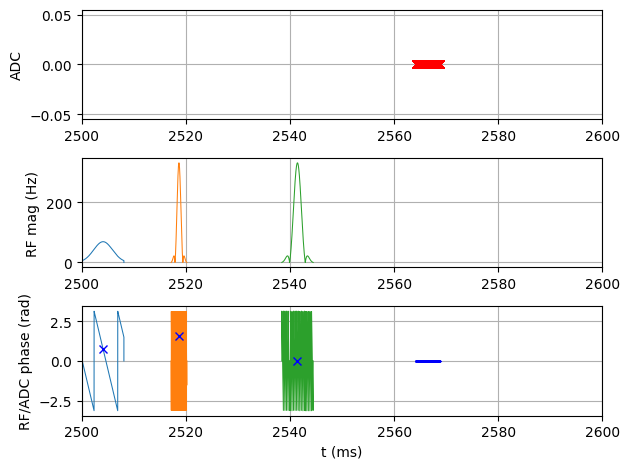

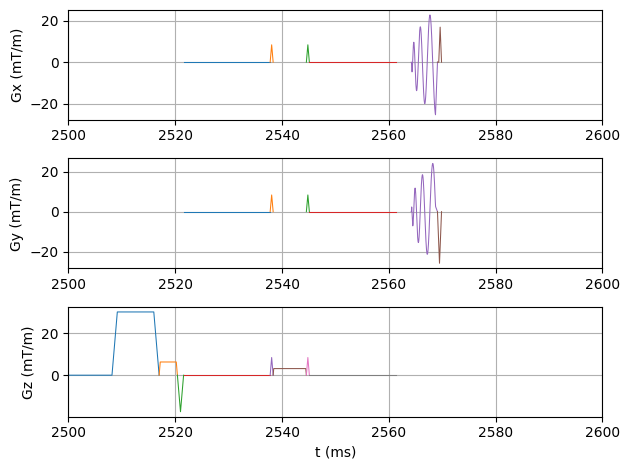

In [178]:
# ---------------------------------------
# Timing QA and quick visual inspection
# ---------------------------------------
ok, err = seq_sp.seq.check_timing()
print(f'Timing check passed: {ok}')
if not ok:
    print('First timing issues:')
    for item in err[:10]:
        print(' -', item)

print(f'Total sequence duration: {seq_sp.seq.duration()[0]:.3f} s')
seq_sp.seq.plot(time_range=[TR_sec*5, TR_sec*5 + 100e-3], grad_disp='mT/m', time_disp='ms')
plt.show()

In [179]:
# -----------------------------
# Export sequence to .seq file
# -----------------------------
version = 'v0.6.0'
out_dir = Path('seq')
out_dir.mkdir(parents=True, exist_ok=True)
accel_tag = str(spiral_accel)
out_name = (
    f'fs_se_dti_spiral_vds_b{int(b_value)}_'
    f'dir{num_dirs}_shot{n_shots}_slice{n_slices}_'
    f'acc{accel_tag}_{version}.seq'
)
out_path = out_dir / out_name

# seq_sp.seq.write(str(out_path))
print(f'Wrote sequence: {out_path}')

# Optional safety check: keep disabled by default to avoid long runtime.
run_safety_check = False
if run_safety_check:
    seq_sp.check_safety_lims(
        r'E:\\MGH\\Healthy_Grad\\asc\\CimaX.asc',
        time_range=[0, min(TR_sec, seq_sp.seq.duration()[0])],
        cns=True,
        do_plot=False,
    )
    print('Safety check complete.')

Wrote sequence: seq\fs_se_dti_spiral_vds_b8000_dir7_shot16_slice3_acc1.5_v0.6.0.seq


In [123]:
# ------------------------------------------------------------------
# Multi-echo FLASH (GRE) sensitivity mapping sequence (new pSeq_Base)
# Geometry is matched to diffusion EPI: FOV, in-plane matrix, slices.
# ------------------------------------------------------------------
system_gre = pp.Opts(
    max_grad=120, grad_unit='mT/m',
    max_slew=100, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_meflash = pSeq_Base(system=system_gre)
seq_meflash.init_seq()

gre_sens = pSeq_GRE_multi_echo(
    system=system_gre,
    fov=fov,
    nx=nx,
    ny=ny,
    slice_thickness=slice_thickness,
    flip_angle=np.deg2rad(5.0),
    rf_duration=0.8e-3,
    readout_time=1e-3,
    te1=2.46e-3,
    echo_spacing=2.46e-3,
    tr=20e-3,
    n_echoes=4,
    readout_mode='monopolar',
    rf_spoil_inc_deg=117.0,
    spoiler_area_ro=1.0 / 1e-3,
    spoiler_area_pe=1.0 / 1e-3,
    spoiler_area_sl=1.0 / 1e-3,
 )
gre_sens.prep()

for rep_idx in range(1):
    for slc_idx, slc_offset in enumerate(slice_offsets):
        for lin_idx in range(ny):
            gre_sens.add_line_to_seq(
                seq_meflash,
                line_index=lin_idx,
                slice_offset=slc_offset,
                rep_idx=rep_idx,
                slc_idx=slc_idx,
                label=True,
            )

ok_me, err_me = seq_meflash.seq.check_timing()
print(f'ME-FLASH timing check passed: {ok_me}')
if not ok_me:
    print('First timing issues:')
    for item in err_me[:10]:
        print(' -', item)

me_timing = gre_sens.get_timing()
print(f"ME-FLASH nominal TR: {me_timing['tr_nominal']*1e3:.3f} ms")
print(f"TEs [ms]: {np.round((me_timing['te1'] + np.arange(me_timing['n_echoes']) * me_timing['echo_spacing']) * 1e3, 3)}")

Prepared multi-echo FLASH blocks:
  Matrix: 160x160, FOV: 200.0 mm
  Readout mode: monopolar
  Inter-echo rewind (constrained): 1.080 ms
  Inter-echo delay block: 0.000 ms
  Echoes: 4, TE1: 2.46 ms, dTE: 2.46 ms
  TR: 20.00 ms, TR fill: 7.17 ms


e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_GRE_multi_echo.py:91: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  self.rf, self.gz, self.gz_reph = pp.make_sinc_pulse(


ME-FLASH timing check passed: True
ME-FLASH nominal TR: 20.000 ms
TEs [ms]: [2.46 4.92 7.38 9.84]


Wrote ME-FLASH sequence: seq\meflash_fov200_mat160x160_slc3_thk5_echo4_v0.2.0.seq
PNS is OK
CNS is OK


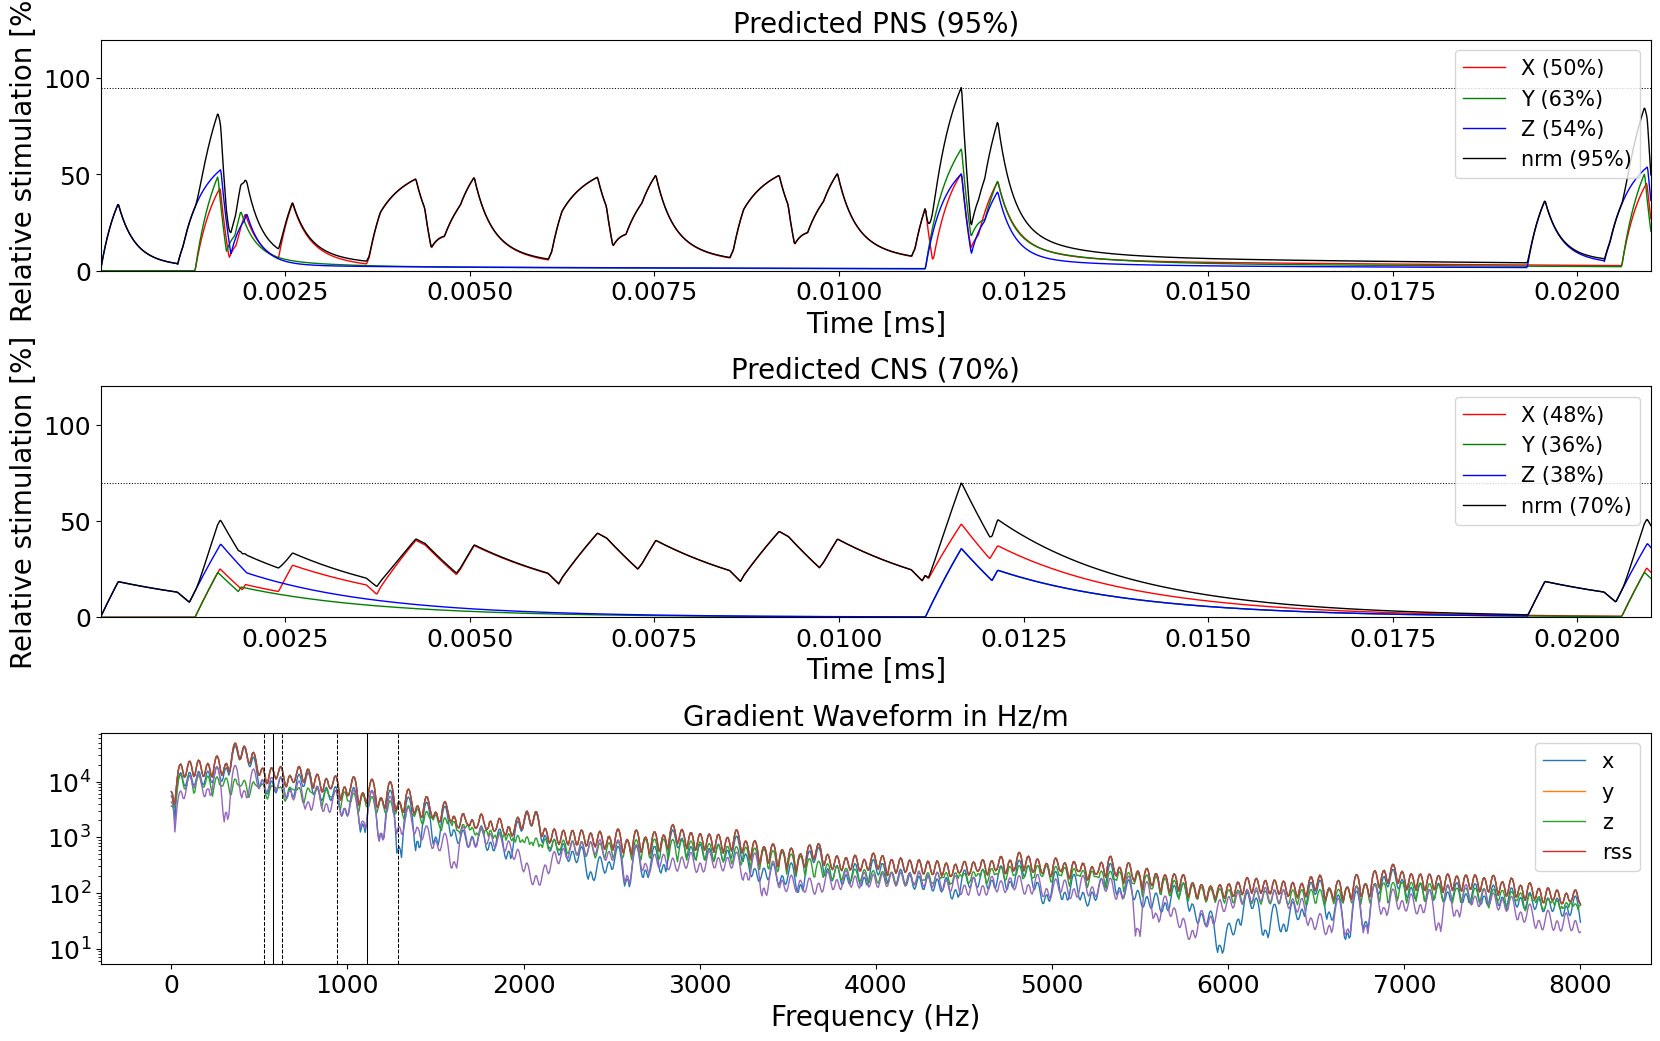

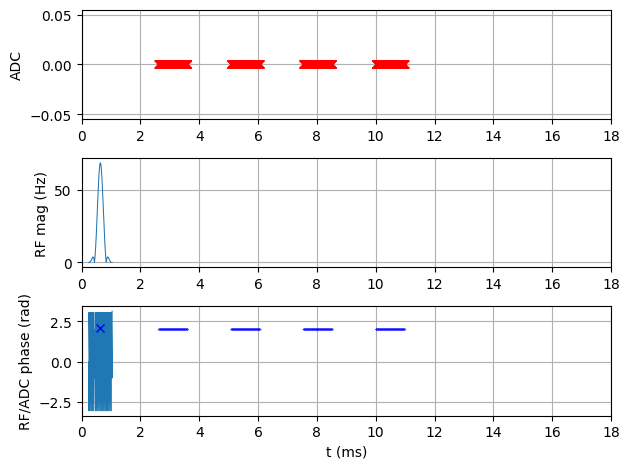

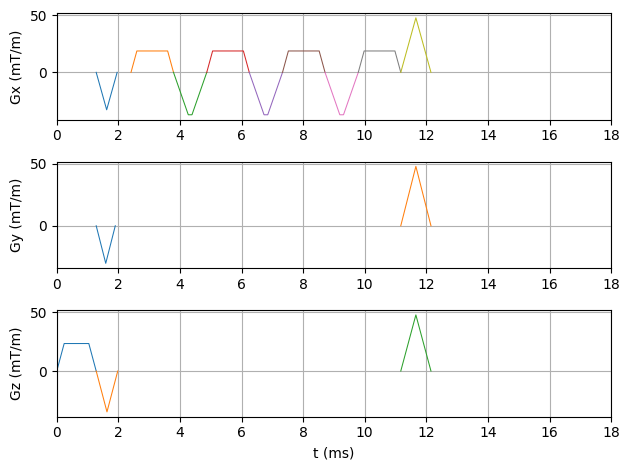

In [124]:
meflash_version = 'v0.2.0'
meflash_out_dir = Path('seq')
meflash_out_dir.mkdir(parents=True, exist_ok=True)
meflash_name = (
    f'meflash_fov{int(fov*1e3)}_'
    f'mat{nx}x{ny}_slc{n_slices}_thk{int(slice_thickness*1e3)}_'
    f'echo{me_timing["n_echoes"]}_{meflash_version}.seq'
 )
meflash_path = meflash_out_dir / meflash_name
# seq_meflash.seq.write(str(meflash_path))
print(f'Wrote ME-FLASH sequence: {meflash_path}')

seq_meflash.check_safety_lims(r'E:\MGH\Healthy_Grad\asc\CimaX.asc', time_range=[0, 21e-3], cns=True, do_plot=True)
seq_meflash.seq.plot(time_disp='ms', grad_disp='mT/m', time_range=[0, 18e-3])

## Twix-Based Spiral NUFFT Reconstruction

This section reconstructs the acquired spiral diffusion Twix data with SigPy NUFFT-SENSE.

Pipeline:
1. Load meflash Twix and estimate slice-wise ESPIRiT coil sensitivity maps.
2. Load spiral diffusion Twix and reorder into canonical `(rep, slc, dir, shot, ch, ro)`.
3. Build NUFFT coordinates from the designed spiral trajectory interleaves.
4. Run direct SENSE reconstruction for each `(rep, slc, dir)`.

In [125]:
from tqdm.auto import tqdm
from scipy.fft import fftshift, ifftshift, ifft2
import sigpy as sp
from sigpy.mri.app import EspiritCalib
from twixtools import read_twix, map_twix


def _ifftc2_local(ksp):
    return fftshift(ifft2(ifftshift(ksp, axes=(-2, -1)), axes=(-2, -1), norm='ortho'), axes=(-2, -1))


def _safe_get_twix_image_obj(mapped_obj):
    if isinstance(mapped_obj, list) and len(mapped_obj) > 0:
        mapped_obj = mapped_obj[-1]
    if isinstance(mapped_obj, dict) and 'image' in mapped_obj:
        return mapped_obj['image']
    raise RuntimeError('Mapped twix object does not contain a readable image block.')


def _infer_axes_from_twix_dims(img_obj, squeezed_shape, role_candidates):
    dims = tuple(getattr(img_obj, 'dims', ()))
    full_shape = tuple(getattr(img_obj, 'shape', ()))
    if len(dims) == 0 or len(full_shape) != len(dims):
        return None

    non_singleton_dims = [d for d, s in zip(dims, full_shape) if int(s) > 1]
    if len(non_singleton_dims) != len(squeezed_shape):
        return None

    dim_to_axis = {d: i for i, d in enumerate(non_singleton_dims)}
    axis_map = {}
    for role, candidates in role_candidates.items():
        hit = None
        for d in candidates:
            if d in dim_to_axis:
                hit = dim_to_axis[d]
                break
        if hit is None:
            return None
        axis_map[role] = hit
    return axis_map


def _infer_axis_map_first_dims(shape, expected):
    axis_map = {}
    used = set()
    for key, size in expected.items():
        matches = [i for i, s in enumerate(shape) if s == size and i not in used]
        if len(matches) == 1:
            axis_map[key] = matches[0]
            used.add(matches[0])
    return axis_map


def _center_crop_or_pad_2d(arr, target_y, target_x):
    out = np.zeros(arr.shape[:-2] + (target_y, target_x), dtype=arr.dtype)
    src_y, src_x = arr.shape[-2], arr.shape[-1]

    copy_y = min(src_y, target_y)
    copy_x = min(src_x, target_x)

    src_y0 = (src_y - copy_y) // 2
    src_x0 = (src_x - copy_x) // 2
    dst_y0 = (target_y - copy_y) // 2
    dst_x0 = (target_x - copy_x) // 2

    out[..., dst_y0:dst_y0 + copy_y, dst_x0:dst_x0 + copy_x] = arr[..., src_y0:src_y0 + copy_y, src_x0:src_x0 + copy_x]
    return out


# Try GPU first; if unavailable, use CPU.
try:
    _sp_device = sp.Device(0)
    _ = _sp_device.xp.zeros(1)
except Exception:
    _sp_device = sp.Device(-1)

print('SigPy reconstruction device:', _sp_device)

SigPy reconstruction device: <CUDA Device 0>


In [167]:
b0_path = Path('scan_data/meas_MID00243_FID16403_meflash_fov200_mat160_slc3_thk5_echo4_v0_2_0.dat')
# spiral_path = Path('scan_data/meas_MID00240_FID16400_fs_se_dti_spiral_vds_b2000_dir7_shot16_slice3_acc8_v0_4_1.dat')
# spiral_path = Path('scan_data/meas_MID00249_FID16409_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc8_v0_5_0.dat')
# spiral_path = Path('scan_data/meas_MID00252_FID16412_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc2_v0_6_0.dat')
# spiral_path = Path('scan_data/meas_MID00253_FID16413_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc1_v0_6_0.dat')
spiral_path = Path('scan_data/meas_MID00254_FID16414_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc1_5_v0_6_0.dat')

In [168]:
# ------------------------------------------------------------------
# Step 1: Load meflash Twix and estimate ESPIRiT sensitivity maps
# ------------------------------------------------------------------
if not b0_path.exists():
    raise FileNotFoundError(f'Could not find b0 Twix file: {b0_path}')

b0_twix_raw = read_twix(str(b0_path), parse_pmu=False)
b0_twix_mapped = map_twix(b0_twix_raw)
b0_img_obj = _safe_get_twix_image_obj(b0_twix_mapped)
b0_raw = np.asarray(b0_img_obj[:]).squeeze()
print('Raw b0 image shape:', b0_raw.shape)

b0_axis_map = _infer_axes_from_twix_dims(
    b0_img_obj,
    b0_raw.shape,
    role_candidates={
        'slc': ('Sli', 'Set'),
        'echo': ('Eco',),
        'ky': ('Lin',),
        'ch': ('Cha',),
        'kx': ('Col',),
    },
)

if b0_axis_map is not None:
    slc_axis = b0_axis_map['slc']
    echo_axis = b0_axis_map['echo']
    ky_axis = b0_axis_map['ky']
    ch_axis = b0_axis_map['ch']
    kx_axis = b0_axis_map['kx']
    print('B0 axis map from TWIX header dims:', b0_axis_map)
else:
    # Fallback: assume (slc, echo, ky, ch, kx) or (echo, slc, ky, ch, kx)
    if b0_raw.ndim != 5:
        raise RuntimeError(f'Expected 5D b0 data, got shape {b0_raw.shape}')
    if b0_raw.shape[0] == n_slices:
        slc_axis, echo_axis, ky_axis, ch_axis, kx_axis = 0, 1, 2, 3, 4
    elif b0_raw.shape[1] == n_slices:
        slc_axis, echo_axis, ky_axis, ch_axis, kx_axis = 1, 0, 2, 3, 4
    else:
        raise RuntimeError('Could not infer b0 axes. Please inspect TWIX dimensions.')

perm_b0 = [slc_axis, echo_axis, ky_axis, ch_axis, kx_axis]
b0_ksp = np.transpose(b0_raw, perm_b0).astype(np.complex64, copy=False)
print('Canonical b0 k-space shape (slc, echo, ky, ch, kx):', b0_ksp.shape)

# FFT-friendly order: (slc, echo, ch, ky, kx)
b0_ksp = np.transpose(b0_ksp, (0, 1, 3, 2, 4))
b0_img_coils = _ifftc2_local(b0_ksp)

n_slc_b0, n_echo_b0, n_ch_b0, n_ky_b0, n_kx_b0 = b0_img_coils.shape
sens_maps = np.zeros((n_slc_b0, n_ch_b0, n_ky_b0, n_kx_b0), dtype=np.complex64)

for slc in tqdm(range(n_slc_b0), desc='ESPIRiT', leave=False):
    ksp_ref = b0_ksp[slc, 0]  # (ch, ky, kx)
    sens_est = EspiritCalib(
        ksp_ref,
        calib_width=32,
        kernel_width=6,
        crop=0,
        device=_sp_device,
        show_pbar=False,
    ).run()

    if hasattr(sens_est, 'get'):
        sens_est = sens_est.get()
    sens_maps[slc] = np.asarray(sens_est, dtype=np.complex64)

print('Sensitivity map shape (slc, ch, y, x):', sens_maps.shape)

Software version: VD/VE (!?)

Scan  0


100%|██████████| 60.1M/60.1M [00:00<00:00, 1.08GB/s]


Scan  1


100%|██████████| 77.6M/77.6M [00:00<00:00, 244MB/s]


Raw b0 image shape: (4, 3, 160, 32, 160)
B0 axis map from TWIX header dims: {'slc': 1, 'echo': 0, 'ky': 2, 'ch': 3, 'kx': 4}
Canonical b0 k-space shape (slc, echo, ky, ch, kx): (3, 4, 160, 32, 160)


ESPIRiT:   0%|          | 0/3 [00:00<?, ?it/s]

Sensitivity map shape (slc, ch, y, x): (3, 32, 160, 160)


In [169]:
# ------------------------------------------------------------------
# Step 2: Load spiral diffusion Twix and reorder to canonical shape
# ------------------------------------------------------------------
if not spiral_path.exists():
    raise FileNotFoundError(f'Could not find spiral Twix file: {spiral_path}')

sp_twix_raw = read_twix(str(spiral_path), parse_pmu=False)
sp_twix_mapped = map_twix(sp_twix_raw)
sp_img_obj = _safe_get_twix_image_obj(sp_twix_mapped)
sp_raw = np.asarray(sp_img_obj[:]).squeeze()
print('Raw spiral image shape:', sp_raw.shape)

if sp_raw.ndim != 6:
    raise RuntimeError(f'Expected 6D spiral data, got shape {sp_raw.shape}')

sp_axis_map = _infer_axes_from_twix_dims(
    sp_img_obj,
    sp_raw.shape,
    role_candidates={
        'rep': ('Rep',),
        'slc': ('Sli', 'Set'),
        'dir': ('Seg', 'Phs', 'Par'),
        'shot': ('Lin', 'Ave'),
        'ch': ('Cha',),
        'ro': ('Col',),
    },
)

if sp_axis_map is not None:
    perm_sp = [
        sp_axis_map['rep'],
        sp_axis_map['slc'],
        sp_axis_map['dir'],
        sp_axis_map['shot'],
        sp_axis_map['ch'],
        sp_axis_map['ro'],
    ]
    sp_data = np.transpose(sp_raw, perm_sp)
    print('Spiral axis map from TWIX header dims:', sp_axis_map)
else:
    expected = {
        'rep': int(num_repeats),
        'slc': int(n_slices),
        'dir': int(num_dirs),
        'shot': int(n_shots),
    }
    axis_guess = _infer_axis_map_first_dims(sp_raw.shape[:4], expected)
    if len(axis_guess) != 4:
        raise RuntimeError(
            'Could not infer spiral data axes from shape. Please inspect TWIX dimensions and update mapping.'
        )
    perm_sp = [axis_guess['rep'], axis_guess['slc'], axis_guess['dir'], axis_guess['shot'], 4, 5]
    sp_data = np.transpose(sp_raw, perm_sp)
    print('Spiral axis map from shape heuristic:', axis_guess)

n_rep, n_slc, n_dir, n_shot, n_ch, n_ro = sp_data.shape
print('Canonical spiral data shape (rep, slc, dir, shot, ch, ro):', sp_data.shape)

if n_shot != n_shots:
    print(f'Warning: TWIX shot dimension ({n_shot}) != planned n_shots ({n_shots}). Using min of both.')
if n_dir != num_dirs:
    print(f'Warning: TWIX dir dimension ({n_dir}) != planned num_dirs ({num_dirs}). Using min of both.')

Software version: VD/VE (!?)

Scan  0


100%|██████████| 60.1M/60.1M [00:00<00:00, 1.01GB/s]

Scan  1



100%|██████████| 751M/751M [00:00<00:00, 3.13GB/s]


Raw spiral image shape: (7, 2, 3, 16, 32, 4528)
Spiral axis map from TWIX header dims: {'rep': 1, 'slc': 2, 'dir': 0, 'shot': 3, 'ch': 4, 'ro': 5}
Canonical spiral data shape (rep, slc, dir, shot, ch, ro): (2, 3, 7, 16, 32, 4528)


In [180]:
# ------------------------------------------------------------------
# Step 3: Build NUFFT coordinates from designed spiral interleaves
# ------------------------------------------------------------------
recon_ny = int(ny)
recon_nx = int(nx)

n_shot_use = min(int(n_shots), int(n_shot))
n_dir_use = min(int(num_dirs), int(n_dir))

traj_by_shot = []
for shot_idx in range(n_shot_use):
    k_shot = np.asarray(spiral_vds.get_adc_ktraj(interleaf=shot_idx))
    if k_shot.size == 0:
        raise RuntimeError(f'Empty trajectory for shot {shot_idx}')
    traj_by_shot.append(k_shot)

# Match trajectory length with measured RO samples.
n_ro_design = min([len(k) for k in traj_by_shot])
n_ro_use = min(int(n_ro), int(n_ro_design))
if n_ro_use < 16:
    raise RuntimeError('Too few readout samples after matching trajectory/data lengths.')

traj_by_shot = [k[:n_ro_use] for k in traj_by_shot]

# Normalize to SigPy coordinate convention [-N/2, N/2].
kx_all = np.concatenate([np.real(k) for k in traj_by_shot])
ky_all = np.concatenate([np.imag(k) for k in traj_by_shot])
kmax_x = max(float(np.max(np.abs(kx_all))), 1e-9)
kmax_y = max(float(np.max(np.abs(ky_all))), 1e-9)

coords_by_shot = []
for k in traj_by_shot:
    coord_y = (np.imag(k) / kmax_y) * (recon_ny / 2.0)
    coord_x = (np.real(k) / kmax_x) * (recon_nx / 2.0)
    coords_by_shot.append(np.stack((coord_y, coord_x), axis=-1).astype(np.float32))

print('Reconstruction matrix:', (recon_ny, recon_nx))
print('Using shots:', n_shot_use, 'Using dirs:', n_dir_use)
print('RO samples used per shot:', n_ro_use)
print('Total NUFFT samples per image:', n_shot_use * n_ro_use)

Reconstruction matrix: (160, 160)
Using shots: 16 Using dirs: 7
RO samples used per shot: 4528
Total NUFFT samples per image: 72448


In [181]:
# ------------------------------------------------------------------
# Step 4: Direct SigPy NUFFT-SENSE reconstruction
# ------------------------------------------------------------------
img_sense_spiral = np.zeros((n_rep, n_slc, n_dir_use, recon_ny, recon_nx), dtype=np.complex64)

# Ensure sensitivity map resolution matches target reconstruction matrix.
sens_use = np.asarray(sens_maps, dtype=np.complex64)
if sens_use.shape[-2:] != (recon_ny, recon_nx):
    sens_use = _center_crop_or_pad_2d(sens_use, recon_ny, recon_nx)

if sens_use.shape[0] != n_slc:
    raise RuntimeError(f'Slice mismatch between sensitivities ({sens_use.shape[0]}) and spiral data ({n_slc}).')
if sens_use.shape[1] != n_ch:
    raise RuntimeError(f'Channel mismatch between sensitivities ({sens_use.shape[1]}) and spiral data ({n_ch}).')

total_items = n_rep * n_slc * n_dir_use
print('Starting NUFFT-SENSE reconstruction ...')
with tqdm(total=total_items, desc='Spiral NUFFT-SENSE', leave=False) as pbar:
    for rep_idx in range(n_rep):
        for slc_idx in range(n_slc):
            mps_gpu = sp.to_device(sens_use[slc_idx], _sp_device)

            for dir_idx in range(n_dir_use):
                # data shape per frame: (shot, ch, ro)
                d_frame = np.asarray(sp_data[rep_idx, slc_idx, dir_idx, :n_shot_use, :, :n_ro_use], dtype=np.complex64)

                # Concatenate shots into one non-Cartesian acquisition.
                y_cat = np.concatenate([d_frame[s] for s in range(n_shot_use)], axis=-1)  # (ch, pts)
                coord_cat = np.concatenate([coords_by_shot[s] for s in range(n_shot_use)], axis=0)  # (pts, 2)

                y_gpu = sp.to_device(y_cat, _sp_device)
                coord_gpu = sp.to_device(coord_cat, _sp_device)

                dcf_gpu = sp.mri.dcf.pipe_menon_dcf(
                    coord_gpu,
                    img_shape=(recon_ny, recon_nx),
                    max_iter=15,
                    show_pbar=False,
                    device=_sp_device,
                )

                app = sp.mri.app.TotalVariationRecon(
                    y=y_gpu,
                    mps=mps_gpu,
                    coord=coord_gpu,
                    weights=dcf_gpu,
                    max_iter=50,
                    lamda=1e-18,
                    solver="PrimalDualHybridGradient",
                    device=_sp_device,
                    show_pbar=False,
                )
                # app = sp.mri.app.SenseRecon(
                #     y=y_gpu,
                #     mps=mps_gpu,
                #     coord=coord_gpu,
                #     weights=dcf_gpu,
                #     max_iter=50,
                #     lamda=1e-1,
                #     solver="PrimalDualHybridGradient",
                #     device=_sp_device,
                #     show_pbar=False,
                # )

                recon_gpu = app.run()
                img_sense_spiral[rep_idx, slc_idx, dir_idx] = np.asarray(sp.to_device(recon_gpu, sp.Device(-1)), dtype=np.complex64)
                pbar.update(1)

print('Reconstruction done. Image shape:', img_sense_spiral.shape)

Starting NUFFT-SENSE reconstruction ...


Spiral NUFFT-SENSE:   0%|          | 0/42 [00:00<?, ?it/s]

Reconstruction done. Image shape: (2, 3, 7, 160, 160)


In [182]:
# ------------------------------------------------------------------
# Step 5: Interactive visualization (rep-averaged, low-flicker)
# ------------------------------------------------------------------
import io
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

img_avg = np.mean(img_sense_spiral, axis=0)  # (slc, dir, y, x)
n_slc_vis = img_avg.shape[0]
n_dir_vis = img_avg.shape[1]

# A global magnitude scale avoids visual pumping when browsing frames.
mag_vmax = float(np.percentile(np.abs(img_avg), 99.5))
if not np.isfinite(mag_vmax) or mag_vmax <= 0:
    mag_vmax = 1.0

slc_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_slc_vis - 1),
    step=1,
    description='show_slc',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

dwi_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_dir_vis - 1),
    step=1,
    description='show_dwi',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

backend_ok = False
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('matplotlib', 'widget')
        backend_ok = True
except Exception:
    backend_ok = False

ui = widgets.HBox([slc_slider, dwi_slider])

if backend_ok:
    # Create once, then update image buffers only (prevents flashing).
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    im0 = ax[0].imshow(
        np.abs(img_avg[0, 0].T),
        cmap='gray',
        vmin=0.0,
        vmax=mag_vmax,
    )
    cb0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
    cb0.set_label('Magnitude')

    im1 = ax[1].imshow(
        np.angle(img_avg[0, 0].T),
        cmap='jet',
        vmin=-np.pi,
        vmax=np.pi,
    )
    cb1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
    cb1.set_label('Phase [rad]')

    def _update_frame(_=None):
        show_slc = int(slc_slider.value)
        show_dwi = int(dwi_slider.value)

        im0.set_data(np.abs(img_avg[show_slc, show_dwi].T))
        im1.set_data(np.angle(img_avg[show_slc, show_dwi].T))

        ax[0].set_title(f'Slice {show_slc} | {dir_labels[show_dwi]} | Magnitude')
        ax[1].set_title(f'Slice {show_slc} | {dir_labels[show_dwi]} | Phase')
        fig.canvas.draw_idle()

    slc_slider.observe(_update_frame, names='value')
    dwi_slider.observe(_update_frame, names='value')
    _update_frame()

    display(widgets.VBox([ui, fig.canvas]))
    print('Live canvas mode: continuous slider updates with reduced flashing.')

else:
    # Fallback: update two image widgets in-place (continuous, no mouse-release needed).
    def _array_to_png_bytes(arr, vmin, vmax, cmap):
        arr = np.asarray(arr, dtype=np.float32)
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
            vmin, vmax = 0.0, 1.0
        norm = np.clip((arr - vmin) / (vmax - vmin), 0.0, 1.0)
        rgba = (cmap(norm) * 255).astype(np.uint8)
        img = Image.fromarray(rgba, mode='RGBA')
        buf = io.BytesIO()
        img.save(buf, format='PNG')
        return buf.getvalue()

    title_mag = widgets.HTML()
    title_phs = widgets.HTML()
    mag_widget = widgets.Image(format='png', layout=widgets.Layout(width='360px', height='360px'))
    phs_widget = widgets.Image(format='png', layout=widgets.Layout(width='360px', height='360px'))

    view = widgets.HBox([
        widgets.VBox([title_mag, mag_widget]),
        widgets.VBox([title_phs, phs_widget]),
    ])

    gray_cmap = plt.get_cmap('gray')
    jet_cmap = plt.get_cmap('jet')

    def _update_widget_images(_=None):
        show_slc = int(slc_slider.value)
        show_dwi = int(dwi_slider.value)

        mag = np.abs(img_avg[show_slc, show_dwi].T)
        phs = np.angle(img_avg[show_slc, show_dwi].T)

        mag_widget.value = _array_to_png_bytes(mag, 0.0, mag_vmax, gray_cmap)
        phs_widget.value = _array_to_png_bytes(phs, -np.pi, np.pi, jet_cmap)

        title_mag.value = f'<b>Slice {show_slc} | {dir_labels[show_dwi]} | Magnitude</b>'
        title_phs.value = f'<b>Slice {show_slc} | {dir_labels[show_dwi]} | Phase</b>'

    slc_slider.observe(_update_widget_images, names='value')
    dwi_slider.observe(_update_widget_images, names='value')
    _update_widget_images()

    display(widgets.VBox([ui, view]))
    print('Widget image fallback mode: continuous slider updates without mouse release.')

Widget image fallback mode: continuous slider updates without mouse release.


In [ ]:
import skope_reader
trigger_skope_delay = 120e-6 # Time from trigger to first time point recorded in skope data
skope_traj_path = 'skope_data/diffusion_eddy_spiral_20260419.h5'
session = skope_reader.Session(skope_traj_path)
print(session)

1 Camera Locator
| 1.1 Field Model 1
2 fs_se_dti_spiral_vds_b8000_acc1.0
3 fs_se_dti_spiral_vds_b8000_acc1.5
4 fs_se_dti_spiral_vds_b8000_acc2.0

